In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Rescaling, RandomFlip, RandomZoom, RandomRotation


In [20]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "original_image/train",
    labels='inferred',
    label_mode='int',
    class_names=None,
    color_mode='grayscale',
    batch_size=32,
    image_size=(48, 48),
    shuffle=True)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "original_image/test",
    labels='inferred',
    label_mode='int',
    class_names=None,
    color_mode='grayscale',
    batch_size=32,
    image_size=(48, 48),
    shuffle=True)

Found 27473 files belonging to 7 classes.
Found 7092 files belonging to 7 classes.


In [21]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, BatchNormalization, GlobalAveragePooling2D, Dropout

In [22]:
model = Sequential([
    Input(shape=(48, 48, 1)),

    # Data Augmentation
    Rescaling(1/255),
    RandomFlip("horizontal"),
    RandomZoom(0.1),
    RandomRotation(0.1),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    #set 2

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    #set 2

    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    
    #Dense layers

    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),

    # last set

    Dense(7, activation='softmax')
])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 48, 48, 1)         0         
                                                                 
 random_flip_1 (RandomFlip)  (None, 48, 48, 1)         0         
                                                                 
 random_zoom_1 (RandomZoom)  (None, 48, 48, 1)         0         
                                                                 
 random_rotation_1 (RandomRo  (None, 48, 48, 1)        0         
 tation)                                                         
                                                                 
 conv2d_6 (Conv2D)           (None, 48, 48, 64)        640       
                                                                 
 batch_normalization_6 (Batc  (None, 48, 48, 64)       256       
 hNormalization)                                      

In [23]:
model.compile(
    optimizer= "adam",
    loss= "sparse_categorical_crossentropy",
    metrics= ["SparseCategoricalAccuracy"]
)

In [24]:
callback = [
    tf.keras.callbacks.ModelCheckpoint(
        "second_model.keras",
        monitor='val_loss',
        verbose=1,
        save_best_only=True,
        save_weights_only=False,
        mode='auto',
        save_freq='epoch',
        initial_value_threshold=None,
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        min_delta=0.01,
        patience=5,
        verbose=1,
        mode='auto',
        baseline=None,
        restore_best_weights=True,
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1,
        mode='auto'
    )
]



In [25]:
import sys
import tensorflow as tf

print("Python:", sys.version)
print("Python path:", sys.executable)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

Python: 3.10.10 (tags/v3.10.10:aad5f6a, Feb  7 2023, 17:20:36) [MSC v.1929 64 bit (AMD64)]
Python path: d:\my_work\facial emotion reco\tf-gpu\Scripts\python.exe
TensorFlow: 2.10.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["SparseCategoricalAccuracy"]
)

model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20,
    callbacks=callback
)

Epoch 1/50
859/859 [==============================] - ETA: 0s - loss: 1.8154 - sparse_categorical_accuracy: 0.2511
Epoch 1: val_loss improved from inf to 1.76789, saving model to second_model.keras
859/859 [==============================] - 333s 383ms/step - loss: 1.8154 - sparse_categorical_accuracy: 0.2511 - val_loss: 1.7679 - val_sparse_categorical_accuracy: 0.2394 - lr: 0.0010
Epoch 2/50
859/859 [==============================] - ETA: 0s - loss: 1.6561 - sparse_categorical_accuracy: 0.3309
Epoch 2: val_loss improved from 1.76789 to 1.46636, saving model to second_model.keras
859/859 [==============================] - 336s 391ms/step - loss: 1.6561 - sparse_categorical_accuracy: 0.3309 - val_loss: 1.4664 - val_sparse_categorical_accuracy: 0.4349 - lr: 0.0010
Epoch 3/50
859/859 [==============================] - ETA: 0s - loss: 1.4718 - sparse_categorical_accuracy: 0.4325
Epoch 3: val_loss improved from 1.46636 to 1.44293, saving model to second_model.keras
859/859 [=================

In [27]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "original_image/test",
    labels='inferred',
    label_mode='int',
    class_names=None,
    color_mode='grayscale',
    batch_size=32,
    image_size=(48, 48),
    shuffle=True)

y_true = []
y_predict = []

for images, labels in test_ds:

    predict =  model.predict(images)
    y_predict.extend(tf.argmax(predict, axis=1).numpy())
    y_true.extend(labels.numpy())

Found 7092 files belonging to 7 classes.
1/1 [==============================] - 0s 139ms/step


In [28]:
%pip install scikit-learn
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.



In [29]:
y_true

[3,
 2,
 2,
 4,
 4,
 0,
 0,
 3,
 6,
 4,
 5,
 4,
 2,
 3,
 3,
 3,
 5,
 0,
 4,
 3,
 3,
 5,
 5,
 4,
 6,
 4,
 3,
 2,
 4,
 3,
 5,
 6,
 3,
 0,
 1,
 4,
 4,
 3,
 3,
 4,
 3,
 6,
 3,
 3,
 4,
 6,
 4,
 2,
 5,
 3,
 3,
 2,
 4,
 3,
 2,
 0,
 3,
 3,
 2,
 4,
 5,
 3,
 0,
 5,
 6,
 6,
 2,
 4,
 3,
 0,
 4,
 4,
 3,
 3,
 6,
 5,
 0,
 4,
 3,
 3,
 0,
 5,
 2,
 6,
 4,
 0,
 2,
 3,
 3,
 3,
 6,
 3,
 4,
 4,
 4,
 1,
 2,
 5,
 0,
 2,
 0,
 3,
 5,
 2,
 3,
 2,
 3,
 0,
 2,
 0,
 4,
 6,
 2,
 4,
 3,
 2,
 3,
 0,
 0,
 2,
 1,
 0,
 2,
 3,
 3,
 0,
 0,
 3,
 2,
 5,
 5,
 3,
 3,
 3,
 5,
 2,
 6,
 3,
 4,
 2,
 4,
 0,
 3,
 6,
 3,
 5,
 3,
 3,
 3,
 3,
 2,
 0,
 4,
 0,
 4,
 5,
 5,
 2,
 3,
 0,
 3,
 5,
 5,
 3,
 3,
 3,
 0,
 3,
 2,
 4,
 4,
 2,
 2,
 0,
 3,
 0,
 3,
 4,
 4,
 3,
 5,
 5,
 4,
 2,
 4,
 5,
 4,
 3,
 5,
 3,
 3,
 5,
 4,
 5,
 4,
 3,
 0,
 6,
 3,
 3,
 5,
 5,
 4,
 4,
 5,
 3,
 1,
 3,
 6,
 2,
 5,
 4,
 6,
 5,
 0,
 6,
 2,
 5,
 6,
 6,
 5,
 3,
 3,
 0,
 0,
 4,
 0,
 2,
 0,
 3,
 3,
 3,
 3,
 4,
 6,
 0,
 2,
 4,
 3,
 0,
 0,
 4,
 0,
 2,
 2,
 2,
 2,
 4,
 4,
 0,


In [30]:
y_predict

[3,
 2,
 0,
 3,
 4,
 0,
 0,
 3,
 6,
 4,
 5,
 4,
 2,
 3,
 3,
 4,
 5,
 0,
 4,
 3,
 2,
 5,
 5,
 0,
 6,
 4,
 3,
 5,
 4,
 3,
 5,
 6,
 3,
 4,
 5,
 4,
 5,
 2,
 3,
 0,
 3,
 6,
 3,
 3,
 4,
 6,
 4,
 5,
 4,
 3,
 3,
 0,
 4,
 3,
 2,
 0,
 3,
 3,
 5,
 4,
 2,
 2,
 0,
 5,
 2,
 6,
 4,
 4,
 3,
 3,
 4,
 4,
 3,
 3,
 6,
 4,
 6,
 4,
 3,
 3,
 5,
 2,
 2,
 6,
 2,
 0,
 5,
 3,
 3,
 3,
 6,
 3,
 4,
 4,
 0,
 0,
 2,
 4,
 0,
 5,
 3,
 4,
 4,
 5,
 3,
 4,
 3,
 2,
 2,
 0,
 4,
 6,
 5,
 0,
 3,
 6,
 3,
 2,
 0,
 5,
 0,
 5,
 2,
 3,
 3,
 2,
 2,
 3,
 2,
 5,
 5,
 3,
 3,
 3,
 5,
 5,
 6,
 3,
 5,
 2,
 5,
 0,
 3,
 2,
 3,
 5,
 3,
 3,
 3,
 3,
 2,
 0,
 5,
 4,
 5,
 5,
 0,
 2,
 0,
 0,
 3,
 5,
 4,
 3,
 3,
 2,
 0,
 3,
 2,
 4,
 5,
 6,
 5,
 6,
 3,
 0,
 3,
 4,
 5,
 3,
 4,
 5,
 4,
 2,
 4,
 2,
 4,
 3,
 5,
 3,
 3,
 4,
 4,
 2,
 4,
 3,
 4,
 6,
 3,
 3,
 2,
 5,
 4,
 4,
 5,
 3,
 1,
 3,
 6,
 2,
 5,
 2,
 6,
 2,
 0,
 2,
 2,
 3,
 6,
 2,
 5,
 3,
 3,
 4,
 5,
 4,
 0,
 2,
 0,
 3,
 3,
 3,
 3,
 4,
 6,
 4,
 4,
 4,
 4,
 0,
 5,
 4,
 0,
 5,
 2,
 0,
 2,
 4,
 4,
 0,


In [31]:
class_name = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
print(classification_report(y_true, y_predict ))

              precision    recall  f1-score   support

           0       0.56      0.54      0.55       946
           1       0.68      0.21      0.32       109
           2       0.42      0.43      0.43      1013
           3       0.88      0.82      0.85      1767
           4       0.56      0.66      0.61      1225
           5       0.52      0.54      0.53      1240
           6       0.79      0.68      0.73       792

    accuracy                           0.63      7092
   macro avg       0.63      0.56      0.57      7092
weighted avg       0.64      0.63      0.63      7092



In [32]:
cm = confusion_matrix(y_true, y_predict)

cm

array([[ 514,    5,  132,   26,  113,  138,   18],
       [  53,   23,   20,    3,    1,    8,    1],
       [ 123,    0,  439,   26,  126,  221,   78],
       [  46,    1,   67, 1451,  127,   46,   29],
       [  62,    0,   78,   59,  814,  202,   10],
       [ 104,    5,  151,   49,  247,  674,   10],
       [  24,    0,  151,   40,   26,   11,  540]], dtype=int64)

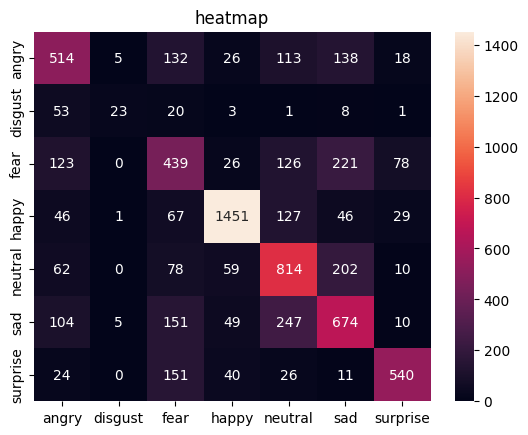

In [33]:
sns.heatmap(cm, annot = True, fmt = 'd', xticklabels=class_name, yticklabels= class_name)
plt.title("heatmap")
plt.show()

In [34]:

print("Model input:", model.input_shape)
print("Model output:", model.output_shape)
print("Classes:", class_name)

Model input: (None, 48, 48, 1)
Model output: (None, 7)
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [35]:
print(train_ds.class_names)
print({name: idx for idx, name in enumerate(train_ds.class_names)})

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [36]:
print("First layer:", model.layers[0])
print("\nFirst 5 layers:")

for layer in model.layers[:5]:
    print(layer.name, "->", layer.__class__.__name__)

First layer: <keras.layers.preprocessing.image_preprocessing.Rescaling object at 0x00000201B7EE0A90>

First 5 layers:
rescaling_1 -> Rescaling
random_flip_1 -> RandomFlip
random_zoom_1 -> RandomZoom
random_rotation_1 -> RandomRotation
conv2d_6 -> Conv2D
